In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.ticker as mtick
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf

In [145]:
df = pd.read_csv('beer_mile_data_CLEAN.csv').iloc[:,1:]
df['date'] = pd.to_datetime(df['date'])
df['Beer'] = df['Beer'].str.title()

print('Data shape (rows, columns):', df.shape)
df.head()

Data shape (rows, columns): (2513, 15)


,Time,Nationality,Gender,Official,Beer,Container,date,lat,lon,temperature,humidity,precipitation,Season,Month,abv
0,287.39,United States,Male,Official,Budweiser,Bottle,2016-08-01,51.507408,-0.127699,15.2,79.0,12.7,Summer,August,5.0
1,294.50,United States,Male,Official,Budweiser,Bottle,2016-07-09,37.780077,-122.420162,16.4,79.0,0.0,Summer,July,5.0
2,297.00,United States,Male,Official,Budweiser,Can,2014-05-27,37.780077,-122.420162,15.8,60.0,0.0,Spring,May,5.0
3,305.20,United States,Male,Official,Budweiser,Bottle,2015-08-09,44.826255,-93.303856,22.4,82.0,2.1,Summer,August,5.0
4,316.00,United States,Male,Official,Budweiser,Bottle,2019-03-17,37.780077,-122.420162,13.3,81.0,0.0,Spring,March,5.0


In [146]:
np.random.seed(1)

month_num = df['date'].dt.month
df['Month_sin'] = np.sin(2*np.pi * month_num / 12)
df['Month_cos'] = np.cos(2*np.pi * month_num / 12)

df.loc[df.Nationality == 'England','Nationality'] = 'United Kingdom'

top_countries = df['Nationality'].value_counts().nlargest(10).index
df['nationality_group'] = df['Nationality'].where(df['Nationality'].isin(top_countries), 'Other')


df['container_can'] = df['Container'].where(df['Container'].isin(['Can']), 'Other')

df = df[df['abv'] >= 5.]

cols_factor = ['Gender','container_can','nationality_group','Beer'] #, 'precipitation_yn'] 
cols_num = ['temperature','precipitation'] 

Xy = df[cols_factor + cols_num + ['Time']].copy()
Xy.loc[:,'TimeLog'] = np.log(Xy.loc[:,'Time'])
Xy = Xy.dropna()
Xy = sm.add_constant(Xy)

ids = np.random.choice(len(Xy), size=len(Xy), replace=False)
train_ids = ids[:int(0.8*len(Xy))]
val_ids = ids[int(0.8*len(Xy)):]

Xy_train = Xy.iloc[train_ids,:]
Xy_val = Xy.iloc[val_ids,:]

x_factor = ''.join([f' + C({v})' for v in cols_factor])
x_factor = x_factor.replace('C(nationality_group)', 'C(nationality_group, Treatment(reference="United States"))')
x_factor = x_factor.replace('C(Beer)', 'C(Beer, Treatment(reference="Budweiser"))')

x_num = ''.join([f' + {v}' for v in cols_num])

model_lr = smf.ols(f'TimeLog ~ + {x_num+x_factor}', data=Xy).fit()
print(model_lr.summary())

                            OLS Regression Results                            
Dep. Variable:                TimeLog   R-squared:                       0.135
Model:                            OLS   Adj. R-squared:                  0.125
Method:                 Least Squares   F-statistic:                     13.19
Date:                Wed, 19 Nov 2025   Prob (F-statistic):           8.12e-45
Time:                        15:27:23   Log-Likelihood:                -500.84
No. Observations:                1887   AIC:                             1048.
Df Residuals:                    1864   BIC:                             1175.
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                                                                                   coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------

In [147]:
params_df = pd.DataFrame({"Coefficient": model_lr.params, "p_value": model_lr.pvalues})

params_df['p_value'] = params_df['p_value'].round(4)
params_df = params_df.iloc[1:,:]

params_df.sort_values(by='p_value', ascending=False, inplace=True)

var_names = []
for v in params_df.index:
    if 'T.' in v:
        s = v.split('T.')[1][:-1]
        if 'Beer' in v:
            s = 'Brand: ' + s
        elif 'nationality' in v:
            s = 'Nationality: ' + s
        elif 'container' in v:
            s = 'Bottle'
        var_names.append(s)
    else:
        var_names.append(v.capitalize())

params_df.index = var_names

In [148]:
params_df_subset = params_df[(params_df.p_value <= 0.2)].copy()

colors = []
for p in params_df_subset["p_value"]:
    if p < 0.05:
        colors.append('red')  # Highly significant
    elif p < 0.1:
        colors.append('tab:blue')  # Marginally significant
    else:
        colors.append('white') 

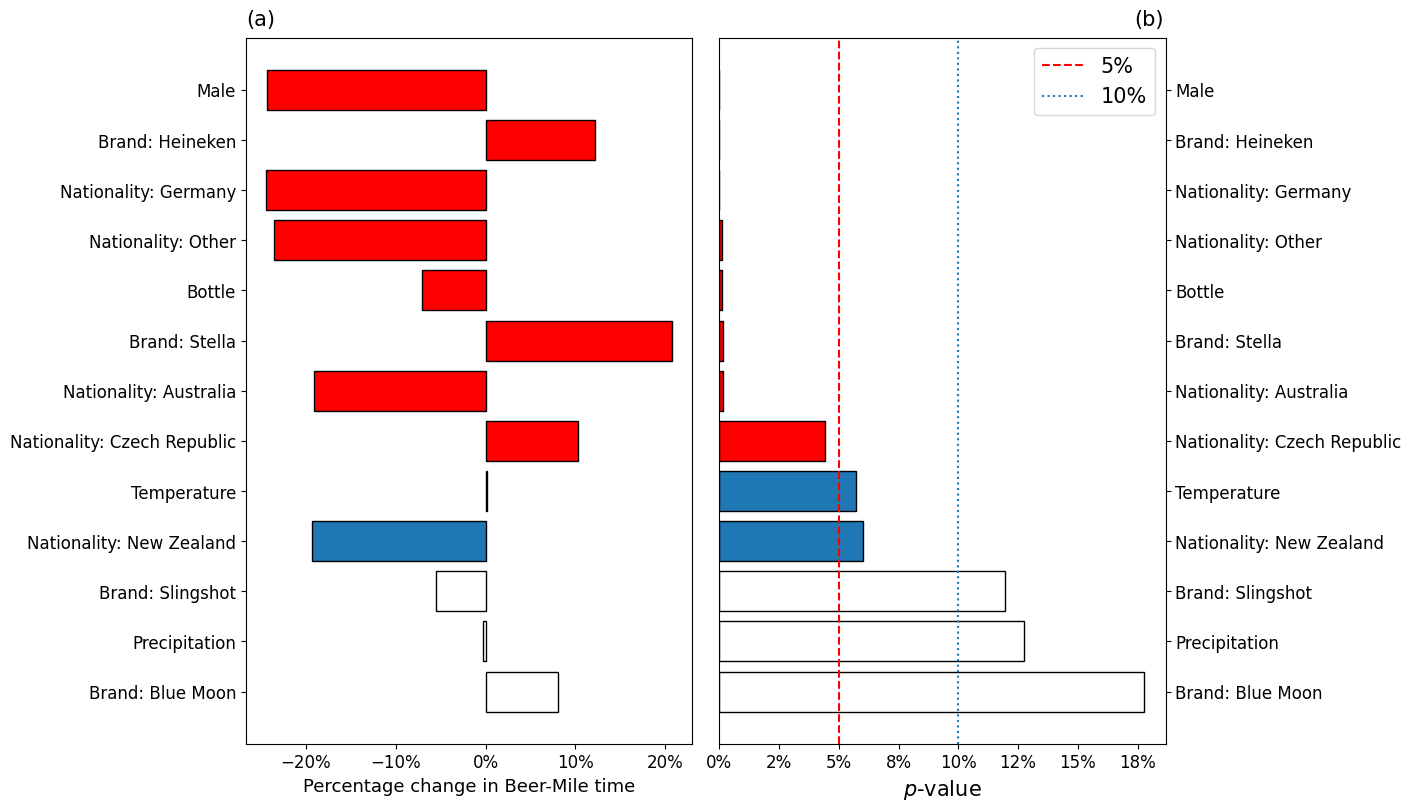

In [149]:

fig, ax = plt.subplots(1,2, figsize=(14, 8), layout='constrained')

ax[1].barh(y=range(len(params_df_subset)), width=params_df_subset["p_value"], color=colors, edgecolor='black')
ax[0].barh(y=range(len(params_df_subset)), width=params_df_subset["Coefficient"], color=colors, edgecolor='black')

ax[1].axvline(0.05, color='red', linestyle='dashed', label='5%')
ax[1].axvline(0.1, color='tab:blue', linestyle='dotted', label='10%')

ax[0].set_yticks(range(len(params_df_subset)), params_df_subset.index)
ax[1].set_yticks(range(len(params_df_subset)), params_df_subset.index)

ax[1].yaxis.tick_right()
ax[1].yaxis.set_label_position("right")

ax[0].set_xlabel('Percentage change in Beer-Mile time', fontsize=13)
ax[1].set_xlabel(r"$p$-value", fontsize=15)

ax[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax[1].xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))

ax[0].tick_params(axis='both', labelsize=12)
ax[1].tick_params(axis='both', labelsize=12)

ax[0].annotate("(a)", xy=(0., 1.04), xycoords="axes fraction", fontsize=15, va="top")
ax[1].annotate("(b)", xy=(0.93, 1.04), xycoords="axes fraction", fontsize=15, va="top");

ax[1].legend(fontsize=15)

plt.show()

In [150]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = Xy[cols_num + cols_factor].copy()
X_vif = pd.get_dummies(X_vif, drop_first=True)
X_vif = X_vif.astype(float)

vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

#vif_data.sort_values(by='VIF').iloc[::-1].reset_index(drop=True)

var_names = []
for v in vif_data.feature:
    if '_' in v:
        s = v.split('_')
        if 'Beer' in v:
            s = 'Beer: ' + s[-1]
        elif 'nationality' in v:
            s = 'Nationality: ' + s[-1]
        elif 'container' in v:
            s = 'No Can Container'
        else:
            s = 'Male'
        var_names.append(s)
    else:
        var_names.append(v.capitalize())

vif_data.index = var_names
vif_data.sort_values(by='VIF', ascending=False, inplace=True)# = vif_data.loc[params_df.index]

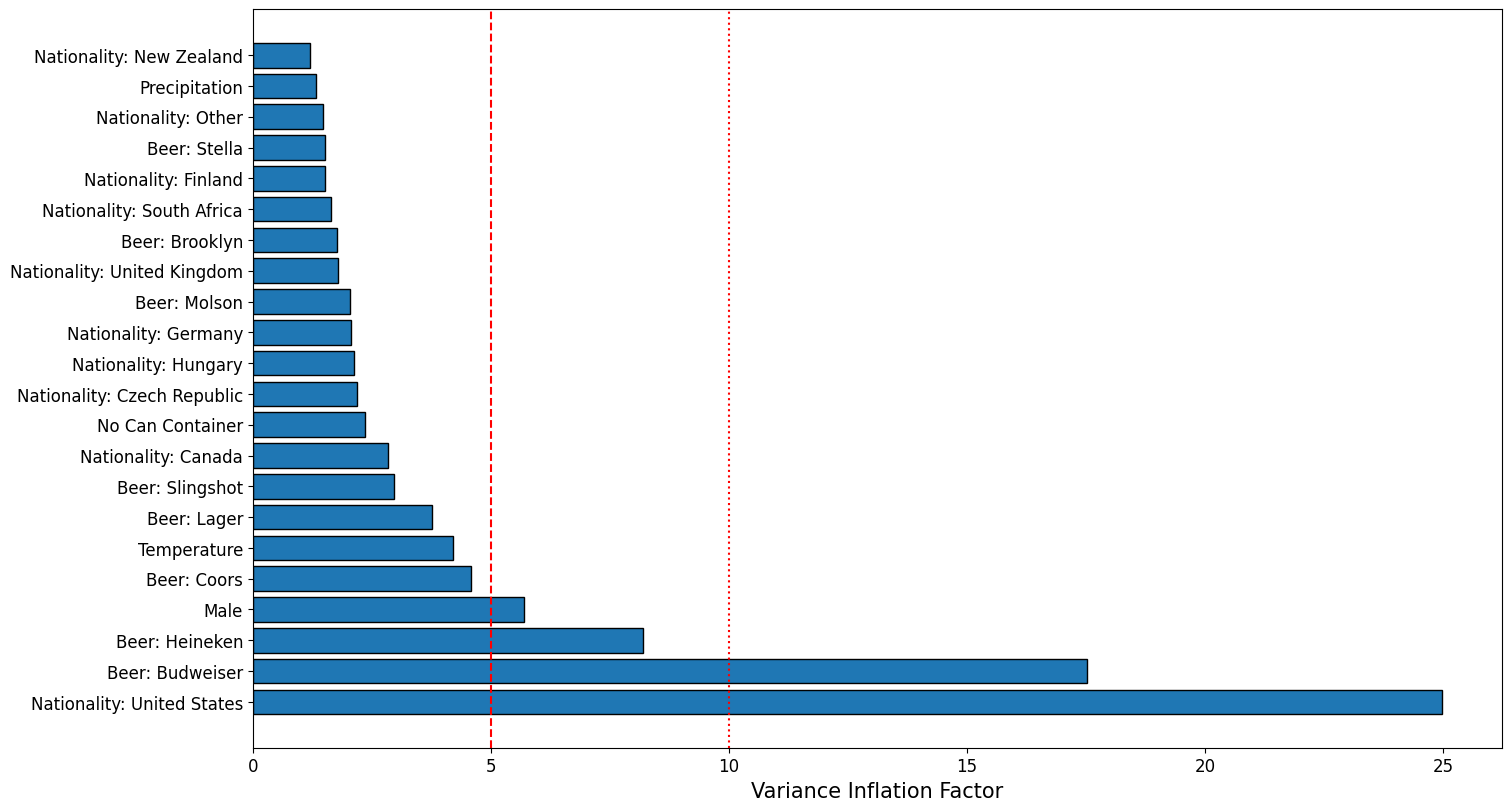

In [151]:
fig, ax = plt.subplots(1,1, figsize=(15, 8), layout='constrained')

ax.barh(y=range(len(params_df)), width=vif_data["VIF"], color='tab:blue', edgecolor='black')

ax.axvline(5, color='red', linestyle='dashed')
ax.axvline(10, color='red', linestyle='dotted')

ax.tick_params(axis='both', labelsize=12)
ax.set_yticks(range(len(vif_data)), vif_data.index)
ax.set_xlabel('Variance Inflation Factor', fontsize=15)

plt.show()